In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../outputs/customer_features.csv')

print("Shape:", df.shape)
print("Columns:",df.columns.tolist())
print("\nRFM columns check:")
for col in ['Recency','Frequency','Monetary']:
    print(f"  {col}: min={df[col].min():.1f}, "
          f"max={df[col].max():.1f},"
          f"mean={df[col].mean():.1f}")
df.head()

Shape: (4228, 16)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'AvgDaysBetweenOrders', 'CLTV', 'CLTV_Tier', 'Churned', 'Log_Recency', 'Log_Frequency', 'Log_Monetary', 'Log_AOV', 'Log_CLTV']

RFM columns check:
  Recency: min=1.0, max=374.0,mean=92.6
  Frequency: min=1.0, max=201.0,mean=4.1
  Monetary: min=2.9, max=105017.2,mean=1255.9


,CustomerID,Recency,Frequency,Monetary,AOV,UniqueProducts,Lifespan,AvgDaysBetweenOrders,CLTV,CLTV_Tier,Churned,Log_Recency,Log_Frequency,Log_Monetary,Log_AOV,Log_CLTV
0,12347,2,7,3783.23,21.495625,101,365,60.833333,300.938750,High,0,1.098612,2.079442,8.238598,3.113321,5.710224
1,12348,249,3,90.20,15.033333,6,109,54.500000,58.568219,Mid,1,5.521461,1.386294,4.513055,2.774670,4.087122
2,12349,19,1,1328.55,19.537500,68,0,0.000000,19.537500,Low,0,2.995732,0.693147,7.192596,3.022252,3.022252
3,12350,310,1,294.40,18.400000,16,0,0.000000,18.400000,Low,1,5.739793,0.693147,5.688330,2.965273,2.965273
4,12352,36,7,1321.99,17.626533,56,260,43.333333,211.276941,High,0,3.610918,2.079442,7.187650,2.924587,5.357892


In [2]:
#Frequency and Monetary: higher value = higher score (1=worst, 5=best)
#Recency: lower value = higher score (inverted)

def rfm_score(df):
    #F and M scores- higher is better
    df['F_Score']=pd.qcut(
        df['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]
    ).astype(int)
    
    df['M_Score']=pd.qcut(
        df['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5]
    ).astype(int)
    
    #R score- inverted
    df['R_Score'] = pd.qcut(
        df['Recency'].rank(method='first'),
        q=5, labels=[5,4,3,2,1]
    ).astype(int)
    
    return df

df=rfm_score(df)

print("Score distributions:")
for score in ['R_Score','F_Score','M_Score']:
    print(f"\n{score}:")
    print(df[score].value_counts().sort_index())
    
    

Score distributions:

R_Score:
R_Score
1    846
2    845
3    846
4    845
5    846
Name: count, dtype: int64

F_Score:
F_Score
1    846
2    845
3    846
4    845
5    846
Name: count, dtype: int64

M_Score:
M_Score
1    846
2    845
3    846
4    845
5    846
Name: count, dtype: int64


In [3]:
print("Top 5 customers by R_Score (having lowest Recency):")
print(df[df['R_Score']==5][['CustomerID','Recency','R_Score']]
      .sort_values('Recency').head())
print("\nBottom 5 customers by R_Score (highest Recency):")
print(df[df['R_Score']==1][['CustomerID','Recency','R_Score']]
      .sort_values('Recency',ascending=False).head())


Top 5 customers by R_Score (having lowest Recency):
      CustomerID  Recency  R_Score
772        13404        1        5
3579       17364        1        5
2849       16322        1        5
3600       17389        1        5
460        12955        1        5

Bottom 5 customers by R_Score (highest Recency):
      CustomerID  Recency  R_Score
1714       14729      374        1
4081       18074      374        1
1015       13747      374        1
3034       16583      374        1
3973       17908      374        1


In [4]:
#Combined score (range 3-15)
df['RFM_Score']=df['R_Score']+df['F_Score']+df['M_Score']

#String label
df['RFM_Label']=(
    df['R_Score'].astype(str)+df['F_Score'].astype(str)+df['M_Score'].astype(str)
)

print("RFM score range: ",df['RFM_Score'].min(),"-", df['RFM_Score'].max())
print("\nRFM_Score distribution:")
print(df['RFM_Score'].value_counts().sort_index())
print("\nSample RFM labels:")
print(df[['CustomerID','R_Score','F_Score','M_Score','RFM_Score','RFM_Label']].head(10))


RFM score range:  3 - 15

RFM_Score distribution:
RFM_Score
3     171
4     359
5     357
6     398
7     369
8     376
9     310
10    337
11    318
12    315
13    296
14    277
15    345
Name: count, dtype: int64

Sample RFM labels:
   CustomerID  R_Score  F_Score  M_Score  RFM_Score RFM_Label
0       12347        5        5        5         15       555
1       12348        1        3        1          5       131
2       12349        4        1        4          9       414
3       12350        1        1        2          4       112
4       12352        3        5        4         12       354
5       12353        1        1        1          3       111
6       12354        1        1        4          6       114
7       12355        1        1        2          4       112
8       12356        4        3        5         12       435
9       12357        4        1        5         10       415


In [5]:
def assign_segment(row):
    r=row['R_Score']
    f=row['F_Score']
    m=row['M_Score']
    score=row['RFM_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 4 and f >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalist'
    elif r == 3 and f >= 3:
        return 'Needs Attention'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2:
        return 'Hibernating'
    else:
        return 'Lost'
    
df['Segment']=df.apply(assign_segment,axis=1)

print("Segment distribution:")
seg_counts=df['Segment'].value_counts()
print(seg_counts)
print(f"\nTotal customers: {len(df)}")
print(f"Segments covered: {df['Segment'].nunique()}")

Segment distribution:
Segment
Champion              938
Lost                  792
Hibernating           687
Needs Attention       508
Loyal Customer        451
At Risk               451
New Customer          302
Potential Loyalist     99
Name: count, dtype: int64

Total customers: 4228
Segments covered: 8


In [6]:
SEGMENT_COLORS={
    'Champion':          '#2ecc71',
    'Loyal Customer':    '#27ae60',
    'Potential Loyalist':'#3498db',
    'New Customer':      '#1abc9c',
    'Needs Attention':   '#f39c12',
    'At Risk':           '#e67e22',
    'Hibernating':       '#e74c3c',
    'Lost':              '#c0392b',
}

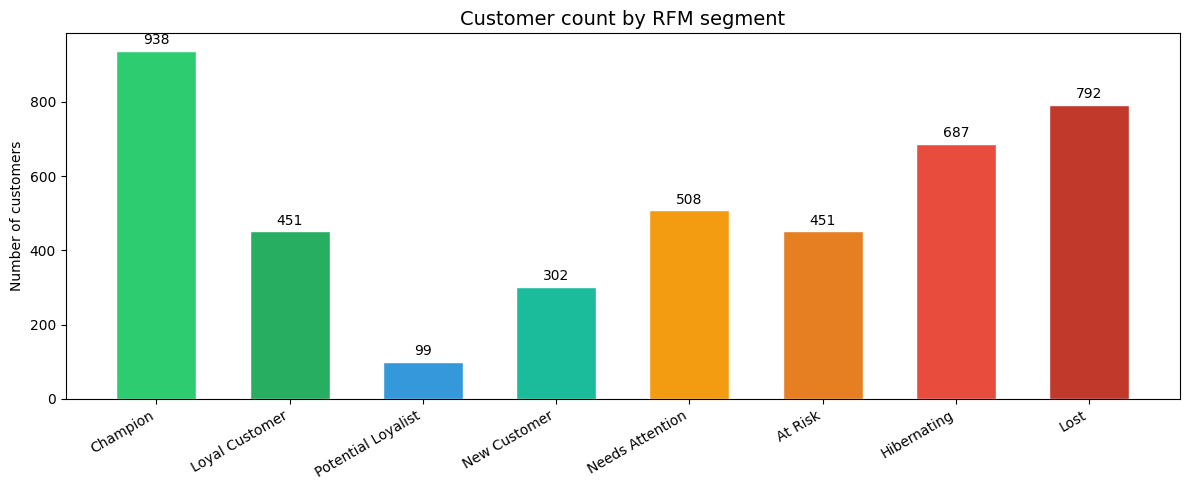

In [7]:
seg_order=[
    'Champion', 'Loyal Customer', 'Potential Loyalist', 'New Customer',
    'Needs Attention', 'At Risk', 'Hibernating', 'Lost'
]
colors=[SEGMENT_COLORS[s] for s in seg_order]
counts=[df[df['Segment']==s].shape[0] for s in seg_order]

plt.figure(figsize=(12,5))
bars=plt.bar(seg_order, counts, color=colors, edgecolor='white', width=0.6)
for bar, count in zip(bars,counts):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+10,
             str(count),ha='center',va='bottom',fontsize=10)
plt.title('Customer count by RFM segment', fontsize=14)
plt.ylabel('Number of customers')  
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.savefig('../outputs/rfm_segment_counts.png',dpi=100,bbox_inches='tight')
plt.show()  


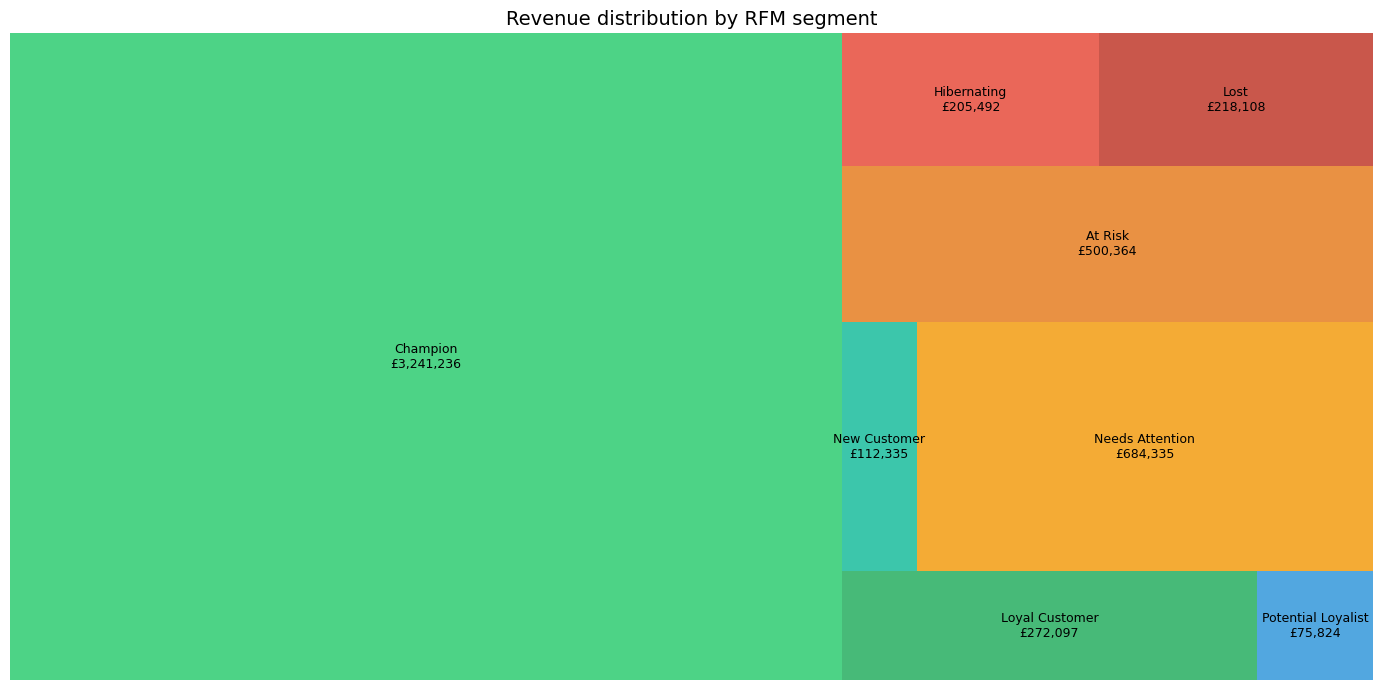

In [8]:
# pip install squarify if not installed
try:
    import squarify
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip',
                           'install', 'squarify', '-q'])
    import squarify

seg_revenue = (
    df.groupby('Segment')['Monetary']
    .sum()
    .reindex(seg_order)
    .fillna(0)
)

seg_revenue=seg_revenue[seg_revenue>0]

plt.figure(figsize=(14, 7))
squarify.plot(
    sizes=seg_revenue.values,
    label=[f"{s}\n£{v:,.0f}" for s, v in zip(seg_revenue.index, seg_revenue.values)],
    color=[SEGMENT_COLORS[s] for s in seg_revenue.index],
    alpha=0.85,
    text_kwargs={'fontsize': 9}
)
plt.title('Revenue distribution by RFM segment', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('../outputs/rfm_treemap.png', dpi=100, bbox_inches='tight')
plt.show()

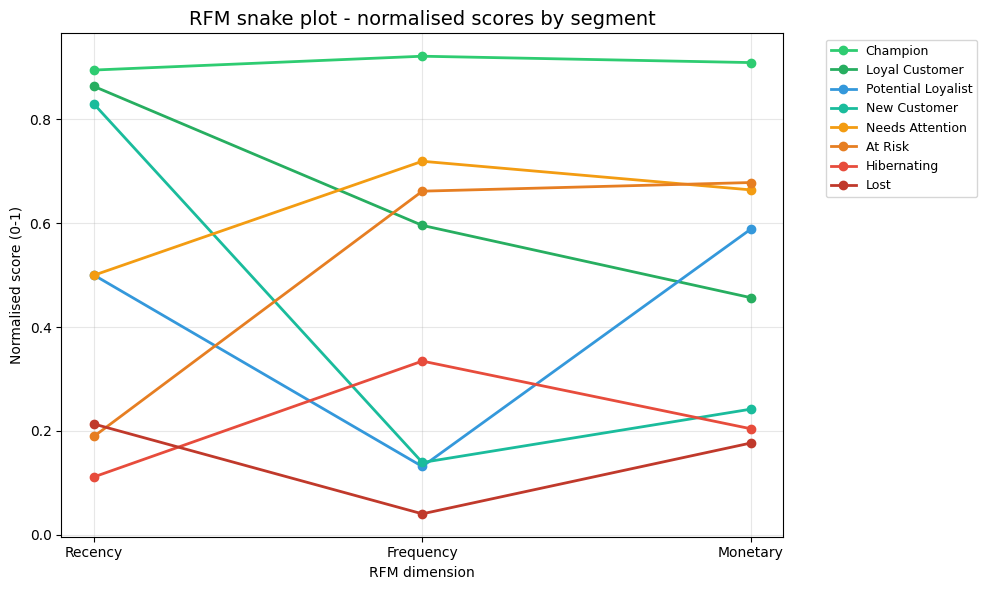

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
df_snake=df.copy()
df_snake[['R_norm','F_norm','M_norm']]=scaler.fit_transform(
    df[['R_Score','F_Score','M_Score']]
)

snake_data=(
    df_snake.groupby('Segment')[['R_norm','F_norm','M_norm']].mean().reset_index()
    .melt(id_vars='Segment', var_name='Metric', value_name='Value')
)
snake_data['Metric']=snake_data['Metric'].map({
    'R_norm': 'Recency', 'F_norm':'Frequency', 'M_norm':'Monetary'
})

plt.figure(figsize=(10,6))
for segment in seg_order:
    data=snake_data[snake_data['Segment']==segment]
    plt.plot(
        data['Metric'], data['Value'],marker='o',linewidth=2, label=segment,color=SEGMENT_COLORS[segment]
    )

plt.title("RFM snake plot - normalised scores by segment", fontsize=14)
plt.ylabel('Normalised score (0-1)')
plt.xlabel('RFM dimension')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/rfm_snake_plot.png',dpi=100,bbox_inches='tight')
plt.show()

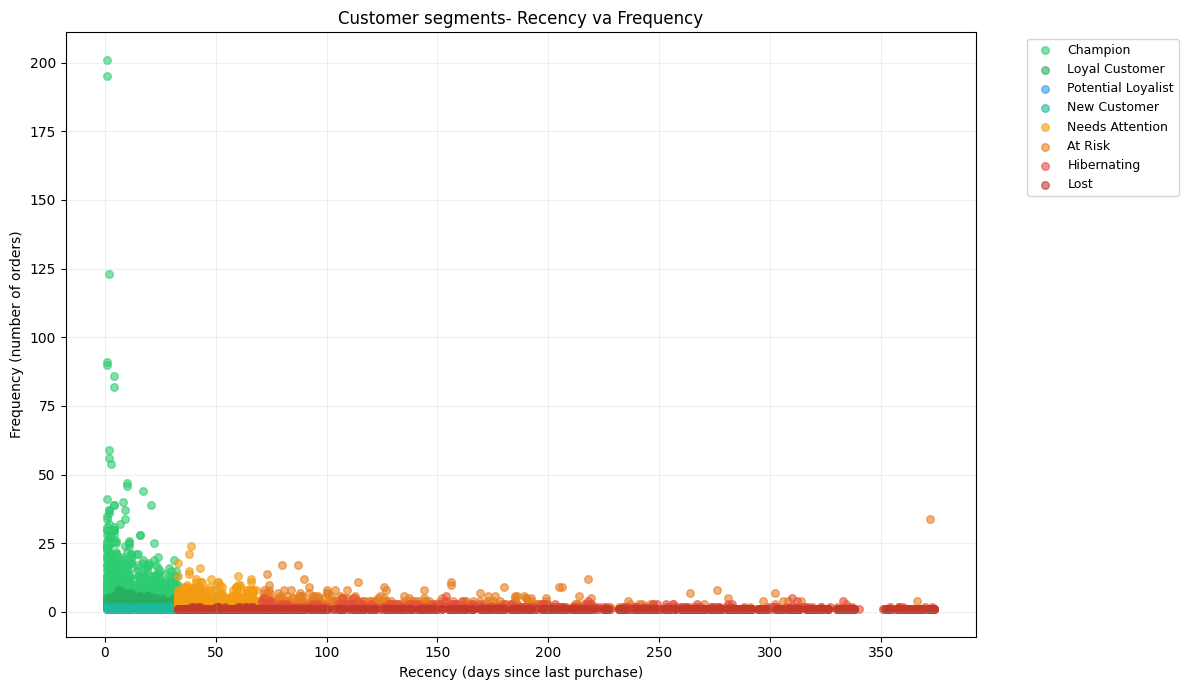

In [10]:
plt.figure(figsize=(12,7))
for segment in seg_order:
    mask=df['Segment']==segment
    plt.scatter(
        df[mask]['Recency'],
        df[mask]['Frequency'],
        c=SEGMENT_COLORS[segment],
        label=segment,
        alpha=0.6, s=30
    )

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency (number of orders)')
plt.title('Customer segments- Recency va Frequency')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left',fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/rfm_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
profile=df.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),
    Avg_CLTV=('CLTV','mean'),
    Total_Revenue=('Monetary','sum'),
    Churn_Rate=('Churned','mean'),
    Avg_RFM_Score=('RFM_Score','mean')    
).round(2)

profile['Revenue_Share_%']=(
    profile['Total_Revenue']/profile['Total_Revenue'].sum()*100
).round(1)

profile=profile.reindex(seg_order)
print(profile.to_string())

                    Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_CLTV  Total_Revenue  Churn_Rate  Avg_RFM_Score  Revenue_Share_%
Segment                                                                                                                                          
Champion                       938        12.84          10.41       3455.48    415.29     3241236.11        0.00          13.91             61.0
Loyal Customer                 451        15.32           2.87        603.32     69.53      272096.85        0.00          10.67              5.1
Potential Loyalist              99        52.32           1.32        765.90     32.83       75823.89        0.00           7.88              1.4
New Customer                   302        18.34           1.23        371.97     24.96      112334.61        0.00           7.84              2.1
Needs Attention                508        49.46           4.34       1347.12    142.87      684334.85        0.00          1

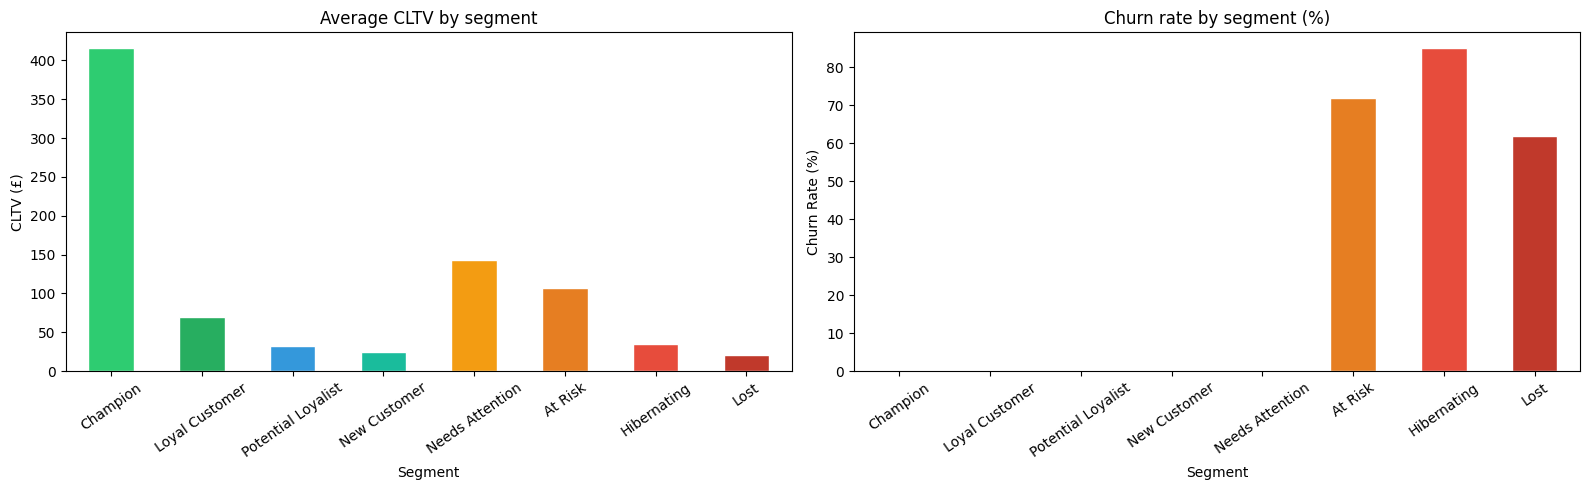

In [12]:
fig,axes=plt.subplots(1,2,figsize=(16,5))

profile['Avg_CLTV'].reindex(seg_order).plot(
    kind='bar',ax=axes[0],color=[SEGMENT_COLORS[s] for s in seg_order],edgecolor='white'
)
axes[0].set_title("Average CLTV by segment")
axes[0].set_ylabel("CLTV (£)")
axes[0].tick_params(axis='x',rotation=35)

(profile['Churn_Rate']*100).reindex(seg_order).plot(
    kind='bar',ax=axes[1],color=[SEGMENT_COLORS[s] for s in seg_order],edgecolor='white'
)
axes[1].set_title("Churn rate by segment (%)")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis='x',rotation=35)

plt.tight_layout()
plt.savefig('../outputs/rfm_segmentation_profile.png',dpi=100,bbox_inches='tight')
plt.show()

In [13]:
print("\n"+"="*65)
print("SEGMENT SUMMARY - BUSINESS VIEW")
print("="*65)
print(f"{'Segment':<22} {'Customers':>9} {'Avg CLTV':>10}"
      f"{'Churn %':>8} {'Rev Share':>10}")
print("-"*65)
for seg in seg_order:
    if seg in profile.index:
        row=profile.loc[seg]
        print(f"{seg:<22} {int(row['Customer_Count']):>9,}"
              f"£{row['Avg_CLTV']:>9,.0f} "
              f"{row['Churn_Rate']*100:>7.1f}% "
              f"{row['Revenue_Share_%']:>9.1f}%")
print("="*65)


SEGMENT SUMMARY - BUSINESS VIEW
Segment                Customers   Avg CLTV Churn %  Rev Share
-----------------------------------------------------------------
Champion                     938£      415     0.0%      61.0%
Loyal Customer               451£       70     0.0%       5.1%
Potential Loyalist            99£       33     0.0%       1.4%
New Customer                 302£       25     0.0%       2.1%
Needs Attention              508£      143     0.0%      12.9%
At Risk                      451£      108    72.0%       9.4%
Hibernating                  687£       35    85.0%       3.9%
Lost                         792£       20    62.0%       4.1%


In [14]:
print("New columns added:")
new_cols=['R_Score', 'F_Score', 'M_Score',
            'RFM_Score', 'RFM_Label', 'Segment']
print(df[new_cols].head(10))

print(f"\nFinal shape: {df.shape}")
print(f"Null Values: {df[new_cols].isnull().sum().sum()}")

df.to_csv('../outputs/customer_rfm.csv',index=False)
print("\nSaved to ../outputs/customer_rfm.csv")

New columns added:
   R_Score  F_Score  M_Score  RFM_Score RFM_Label          Segment
0        5        5        5         15       555         Champion
1        1        3        1          5       131      Hibernating
2        4        1        4          9       414     New Customer
3        1        1        2          4       112             Lost
4        3        5        4         12       354  Needs Attention
5        1        1        1          3       111             Lost
6        1        1        4          6       114             Lost
7        1        1        2          4       112             Lost
8        4        3        5         12       435   Loyal Customer
9        4        1        5         10       415     New Customer

Final shape: (4228, 22)
Null Values: 0

Saved to ../outputs/customer_rfm.csv
